# Real MS/MS retrieval with MassSpecGym and PennyLane

This notebook is a small, reproducible first test using public measured MS/MS spectra. It compares classical spectrum similarity with a small PennyLane feature-interaction kernel.

The goal is not to claim a quantum advantage. The goal is to check whether an uncertainty-aware, multiscale representation keeps related spectra together better than simple peak matching.

## What this notebook does

- downloads the public MassSpecGym v1.5 table;
- keeps a manageable subset for Colab;
- pairs two spectra from the same molecule;
- filters candidates by precursor m/z and adduct when possible;
- compares cosine, tolerance, soft-peak, and wavelet representations; and
- compares independent PennyLane feature encoding with a small `ZZ` interaction graph.

This is a paired retrieval smoke test. It is useful for checking robustness to real spectrum variation, but it is not a final benchmark of de novo identification or a quantum speedup experiment.

In [1]:
%pip -q install pennylane==0.45.1 huggingface_hub PyWavelets scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 45.1 MB/s eta 0:00:00


In [2]:
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pennylane as qml
import pywt
from huggingface_hub import hf_hub_download
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
rng = np.random.default_rng(7)

# These settings keep the first Colab run small. Increase them after it works.
ROWS_TO_READ = 20_000
MAX_CANDIDATES = 100
N_QUERIES = 20
MZ_BIN_WIDTH = 1.0
MZ_MAX = 1000.0
MASS_TOLERANCE = 0.02
OUTPUT_DIR = Path('/content/aug20_msms_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('PennyLane:', qml.__version__)
print('Output folder:', OUTPUT_DIR)

PennyLane: 0.45.1
Output folder: /content/aug20_msms_outputs


## 1. Download a real public spectrum table

Only the requested TSV file is downloaded. Reading `nrows` keeps the first run manageable; the full benchmark should use the official files and splits later.

In [3]:
DATASET_REPO = 'roman-bushuiev/MassSpecGym'
DATASET_FILE = 'data/MassSpecGym1.5.tsv'

dataset_path = hf_hub_download(
    repo_id=DATASET_REPO,
    filename=DATASET_FILE,
    repo_type='dataset'
)

raw = pd.read_csv(dataset_path, sep='\t', nrows=ROWS_TO_READ)
print('Downloaded:', dataset_path)
print('Rows read:', len(raw))
print('Columns:', list(raw.columns))
raw.head(3)

data/MassSpecGym1.5.tsv: reconstructing file:   0%|          |  0.00B /  261MB            

data/MassSpecGym1.5.tsv: downloading bytes:           |  0.00B            

Downloaded: /root/.cache/huggingface/hub/datasets--roman-bushuiev--MassSpecGym/snapshots/d2e86d0c3bd905a6d578c0dd6053ed2bd41f9c2a/data/MassSpecGym1.5.tsv
Rows read: 20000
Columns: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct', 'instrument_type', 'collision_energy', 'fold', 'simulation_challenge']


,identifier,mzs,intensities,smiles,inchikey,formula,precursor_formula,parent_mass,precursor_mz,adduct,instrument_type,collision_energy,fold,simulation_challenge
0,MassSpecGymID0000001,"91.0542,125.0233,154.0499,155.0577,185.0961,20...","0.24524524524524524,1.0,0.08008008008008008,0....",COc1cc([C@H](Cc2ccccc2)NC(C)=O)oc(=O)c1,VFMQMACUYWGDOJ,C16H17NO4,C16H18NO4,287.115224,288.1225,[M+H]+,Orbitrap,30.0,train,True
1,MassSpecGymID0000002,"91.0542,125.0233,155.0577,185.0961,229.0859,24...","0.0990990990990991,0.28128128128128127,0.04004...",COc1cc([C@H](Cc2ccccc2)NC(C)=O)oc(=O)c1,VFMQMACUYWGDOJ,C16H17NO4,C16H18NO4,287.115224,288.1225,[M+H]+,Orbitrap,20.0,train,True
2,MassSpecGymID0000003,"69.0343,91.0542,125.0233,127.039,153.0699,154....","0.03403403403403404,0.31431431431431434,1.0,0....",COc1cc([C@H](Cc2ccccc2)NC(C)=O)oc(=O)c1,VFMQMACUYWGDOJ,C16H17NO4,C16H18NO4,287.115224,288.1225,[M+H]+,Orbitrap,40.0,train,True


## 2. Keep comparable spectra

To keep this first comparison interpretable, the notebook prefers real (not challenge-simulation) spectra, one common adduct, and one instrument type when enough rows are available. If a filter leaves too few rows, it falls back automatically and prints what it used.

In [4]:
df = raw.copy()
required = ['mzs', 'intensities', 'inchikey', 'precursor_mz']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

# Remove rows marked as simulated when that column is present.
if 'simulation_challenge' in df.columns:
    simulated = df['simulation_challenge'].astype(str).str.lower().isin(['true', '1', 'yes'])
    if (~simulated).sum() >= 100:
        df = df.loc[~simulated].copy()

df = df.dropna(subset=required).copy()

def prefer_value(frame, column, preferred):
    if column not in frame.columns:
        return frame, None
    counts = frame[column].value_counts(dropna=True)
    if preferred in counts.index and counts[preferred] >= 100:
        return frame.loc[frame[column] == preferred].copy(), preferred
    if len(counts) and counts.iloc[0] >= 100:
        value = counts.index[0]
        return frame.loc[frame[column] == value].copy(), value
    return frame, 'all values'

df, selected_adduct = prefer_value(df, 'adduct', '[M+H]+')
df, selected_instrument = prefer_value(df, 'instrument_type', 'Orbitrap')
print('Rows after filtering:', len(df))
print('Adduct setting:', selected_adduct)
print('Instrument setting:', selected_instrument)
print('Unique molecules:', df['inchikey'].nunique())

Rows after filtering: 3341
Adduct setting: [M+H]+
Instrument setting: Orbitrap
Unique molecules: 277


## 3. Parse and normalize peak lists

In [5]:
def parse_spectrum(mz_text, intensity_text):
    mz = np.fromstring(str(mz_text), sep=',', dtype=float)
    intensity = np.fromstring(str(intensity_text), sep=',', dtype=float)
    n = min(len(mz), len(intensity))
    mz, intensity = mz[:n], intensity[:n]
    keep = np.isfinite(mz) & np.isfinite(intensity) & (intensity >= 0)
    mz, intensity = mz[keep], intensity[keep]
    if len(intensity) == 0 or intensity.max() == 0:
        raise ValueError('Spectrum has no positive intensities')
    intensity = intensity / intensity.max()
    order = np.argsort(mz)
    return mz[order], intensity[order]

def spectrum_from_row(row):
    return parse_spectrum(row['mzs'], row['intensities'])

# Remove malformed lists before making pairs.
valid_rows = []
for idx, row in df.iterrows():
    try:
        mz, intensity = spectrum_from_row(row)
        if len(mz) >= 2:
            valid_rows.append(idx)
    except (ValueError, TypeError):
        pass
df = df.loc[valid_rows].reset_index(drop=True)
print('Rows with usable peak lists:', len(df))

example_mz, example_intensity = spectrum_from_row(df.iloc[0])
print('Example peaks:', len(example_mz))
print('First five peaks:', list(zip(example_mz[:5], example_intensity[:5])))

Rows with usable peak lists: 3337
Example peaks: 207
First five peaks: [(np.float64(77.977242), np.float64(0.0003726083575364188)), (np.float64(78.066887), np.float64(0.00043936636674482793)), (np.float64(79.629524), np.float64(0.000453356252465211)), (np.float64(80.878296), np.float64(0.0004715389980320781)), (np.float64(83.81282), np.float64(0.00045468984702022017))]


## 4. Make a paired real-data retrieval set

For this first test, each molecule contributes one reference spectrum and one different query spectrum. The correct answer is therefore known: the query's `inchikey` should rank its matching reference highly. This measures stability across real measurements, not generalization to an unseen chemical.

In [6]:
groups = {key: group for key, group in df.groupby('inchikey', sort=False) if len(group) >= 2}
keys = list(groups)
rng.shuffle(keys)
keys = keys[:MAX_CANDIDATES]

if len(keys) < 10:
    raise ValueError('Fewer than 10 molecules have two usable spectra in this subset. Increase ROWS_TO_READ.')

library = pd.DataFrame([groups[key].iloc[0] for key in keys]).reset_index(drop=True)
queries = pd.DataFrame([groups[key].iloc[1] for key in keys[:N_QUERIES]]).reset_index(drop=True)

print('Reference candidates:', len(library))
print('Query spectra:', len(queries))
print('Every query has a matching reference:', set(queries['inchikey']).issubset(set(library['inchikey'])))
library[['inchikey', 'precursor_mz']].head(3)

Reference candidates: 100
Query spectra: 20
Every query has a matching reference: True


,inchikey,precursor_mz
0,XKJMBINCVNINCA,249.019
1,LJUQGASMPRMWIW,147.092
2,ZJUKTBDSGOFHSH,385.129


## 5. Classical spectrum representations

In [7]:
N_BINS = int(MZ_MAX / MZ_BIN_WIDTH)

def binned_spectrum(row):
    mz, intensity = spectrum_from_row(row)
    vector = np.zeros(N_BINS, dtype=float)
    bins = np.floor(mz / MZ_BIN_WIDTH).astype(int)
    keep = (bins >= 0) & (bins < N_BINS)
    np.add.at(vector, bins[keep], intensity[keep])
    norm = np.linalg.norm(vector)
    return vector / norm if norm else vector

def tolerance_similarity(query_row, reference_row, tolerance=MASS_TOLERANCE):
    q_mz, q_i = spectrum_from_row(query_row)
    r_mz, r_i = spectrum_from_row(reference_row)
    differences = np.abs(q_mz[:, None] - r_mz[None, :])
    nearest = differences.argmin(axis=1)
    distances = differences[np.arange(len(q_mz)), nearest]
    numerator = np.sum(q_i * r_i[nearest] * (distances <= tolerance))
    denominator = np.linalg.norm(q_i) * np.linalg.norm(r_i)
    return float(numerator / denominator) if denominator else 0.0

def soft_peak_similarity(query_row, reference_row, sigma=0.02):
    q_mz, q_i = spectrum_from_row(query_row)
    r_mz, r_i = spectrum_from_row(reference_row)
    kernel = np.exp(-0.5 * ((q_mz[:, None] - r_mz[None, :]) / sigma) ** 2)
    numerator = q_i @ kernel @ r_i
    q_self = q_i @ np.exp(-0.5 * ((q_mz[:, None] - q_mz[None, :]) / sigma) ** 2) @ q_i
    r_self = r_i @ np.exp(-0.5 * ((r_mz[:, None] - r_mz[None, :]) / sigma) ** 2) @ r_i
    denominator = np.sqrt(q_self * r_self)
    return float(numerator / denominator) if denominator else 0.0

library_binned = np.vstack([binned_spectrum(row) for _, row in library.iterrows()])
query_binned = np.vstack([binned_spectrum(row) for _, row in queries.iterrows()])
print('Binned vector shape:', library_binned.shape)

Binned vector shape: (100, 1000)


## 6. Apply the chemistry-aware candidate filter

This is a simple first filter, not a complete structure validator. It keeps candidates with the same adduct and a nearby precursor m/z. If that would remove every candidate, the notebook falls back to a wider set so the run can still be inspected.

In [8]:
def candidate_mask(query_row, library_frame, tolerance=MASS_TOLERANCE):
    mask = np.ones(len(library_frame), dtype=bool)
    if 'adduct' in library_frame.columns and pd.notna(query_row.get('adduct', np.nan)):
        mask &= library_frame['adduct'].to_numpy() == query_row['adduct']
    if 'precursor_mz' in library_frame.columns and pd.notna(query_row['precursor_mz']):
        mass_mask = np.abs(library_frame['precursor_mz'].to_numpy(float) - float(query_row['precursor_mz'])) <= tolerance
        strict = mask & mass_mask
        if strict.sum() >= 2:
            return strict
    if mask.sum() >= 2:
        return mask
    return np.ones(len(library_frame), dtype=bool)

def summarize_ranks(result):
    return {
        'queries': len(result),
        'top_1': float((result['rank'] <= 1).mean()),
        'top_5': float((result['rank'] <= 5).mean()),
        'top_10': float((result['rank'] <= 10).mean()),
        'median_rank': float(result['rank'].median()),
    }

def rank_matrix(score_matrix, query_frame, library_frame, method_name):
    rows = []
    for q_idx, query_row in query_frame.iterrows():
        allowed = candidate_mask(query_row, library_frame)
        masked_scores = np.where(allowed, score_matrix[q_idx], -np.inf)
        order = np.argsort(-masked_scores)
        true_id = query_row['inchikey']
        true_positions = np.where(library_frame['inchikey'].to_numpy()[order] == true_id)[0]
        rank = int(true_positions[0] + 1) if len(true_positions) else len(order) + 1
        rows.append({'query_index': q_idx, 'method': method_name, 'rank': rank, 'candidate_count': int(allowed.sum())})
    return pd.DataFrame(rows)

In [9]:
cosine_scores = cosine_similarity(query_binned, library_binned)
tolerance_scores = np.array([[tolerance_similarity(q, r) for _, r in library.iterrows()] for _, q in queries.iterrows()])
soft_scores = np.array([[soft_peak_similarity(q, r) for _, r in library.iterrows()] for _, q in queries.iterrows()])

classical_results = pd.concat([
    rank_matrix(cosine_scores, queries, library, 'binned cosine'),
    rank_matrix(tolerance_scores, queries, library, 'tolerance peak'),
    rank_matrix(soft_scores, queries, library, 'soft peak'),
], ignore_index=True)

classical_summary = pd.DataFrame([summarize_ranks(group) | {'method': name} for name, group in classical_results.groupby('method')])
classical_summary[['method', 'top_1', 'top_5', 'top_10', 'median_rank']]

,method,top_1,top_5,top_10,median_rank
0,binned cosine,1.00,1.0,1.0,1.0
1,soft peak,1.00,1.0,1.0,1.0
2,tolerance peak,0.95,1.0,1.0,1.0



The wavelet features are computed from the binned spectrum. The six scales summarize average and maximum coefficient magnitude. This is a compact representation for a first test; it is not meant to be the final feature design.

In [10]:
WAVELET_SCALES = np.array([1, 2, 4, 8, 16, 32])

def wavelet_features(row):
    vector = binned_spectrum(row)
    coefficients, _ = pywt.cwt(vector, WAVELET_SCALES, 'mexh')
    features = np.concatenate([
        np.mean(np.abs(coefficients), axis=1),
        np.max(np.abs(coefficients), axis=1),
    ])
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    norm = np.linalg.norm(features)
    return features / norm if norm else features

library_wavelet = np.vstack([wavelet_features(row) for _, row in library.iterrows()])
query_wavelet = np.vstack([wavelet_features(row) for _, row in queries.iterrows()])
wavelet_scores = cosine_similarity(query_wavelet, library_wavelet)
wavelet_results = rank_matrix(wavelet_scores, queries, library, 'wavelet cosine')
wavelet_summary = pd.DataFrame([summarize_ranks(wavelet_results) | {'method': 'wavelet cosine'}])

summary = pd.concat([classical_summary, wavelet_summary], ignore_index=True)
summary[['method', 'top_1', 'top_5', 'top_10', 'median_rank']]

,method,top_1,top_5,top_10,median_rank
0,binned cosine,1.00,1.00,1.00,1.0
1,soft peak,1.00,1.00,1.00,1.0
2,tolerance peak,0.95,1.00,1.00,1.0
3,wavelet cosine,0.75,0.85,0.85,1.0




Only six wavelet features are sent to the circuit so that the statevector simulation stays quick in Colab. The independent circuit is the baseline. The interaction circuit adds a sparse chain of `ZZ` terms whose angles depend on the feature values. This tests the representation idea; it does not simulate molecular electronic structure.

In [11]:
N_QUBITS = 6
GAMMA = 0.35
feature_columns = np.arange(N_QUBITS)
library_qfeatures = library_wavelet[:, feature_columns]
query_qfeatures = query_wavelet[:, feature_columns]

edges = [(i, i + 1, 1.0) for i in range(N_QUBITS - 1)]
edges += [(0, 2, 0.5), (1, 3, 0.5), (2, 4, 0.5)]
dev = qml.device('default.qubit', wires=N_QUBITS)

def encode_features(x):
    for wire, value in enumerate(x):
        qml.RY(np.pi * float(value), wires=wire)

@qml.qnode(dev)
def independent_state(x):
    encode_features(x)
    return qml.state()

@qml.qnode(dev)
def interaction_state(x):
    encode_features(x)
    for j, k, weight in edges:
        # IsingZZ(phi) applies exp(-i * phi/2 * Z_j Z_k).
        qml.IsingZZ(2 * GAMMA * weight * float(x[j]) * float(x[k]), wires=[j, k])
    return qml.state()

def state_kernel(query_features, library_features, state_function):
    library_states = [np.asarray(state_function(x)) for x in library_features]
    query_states = [np.asarray(state_function(x)) for x in query_features]
    return np.array([[abs(np.vdot(q_state, r_state)) ** 2 for r_state in library_states] for q_state in query_states])

start = time.time()
independent_scores = state_kernel(query_qfeatures, library_qfeatures, independent_state)
interaction_scores = state_kernel(query_qfeatures, library_qfeatures, interaction_state)
print(f'Circuit calculations finished in {time.time() - start:.2f} seconds')

independent_results = rank_matrix(independent_scores, queries, library, 'PennyLane independent')
interaction_results = rank_matrix(interaction_scores, queries, library, 'PennyLane ZZ interaction')
quantum_results = pd.concat([independent_results, interaction_results], ignore_index=True)
quantum_summary = pd.DataFrame([summarize_ranks(group) | {'method': name} for name, group in quantum_results.groupby('method')])

all_summary = pd.concat([summary, quantum_summary], ignore_index=True)
all_summary[['method', 'top_1', 'top_5', 'top_10', 'median_rank']]

Circuit calculations finished in 0.45 seconds


,method,top_1,top_5,top_10,median_rank
0,binned cosine,1.00,1.00,1.00,1.0
1,soft peak,1.00,1.00,1.00,1.0
2,tolerance peak,0.95,1.00,1.00,1.0
3,wavelet cosine,0.75,0.85,0.85,1.0
4,PennyLane ZZ interaction,0.50,0.70,0.75,1.5
5,PennyLane independent,0.50,0.70,0.75,1.5


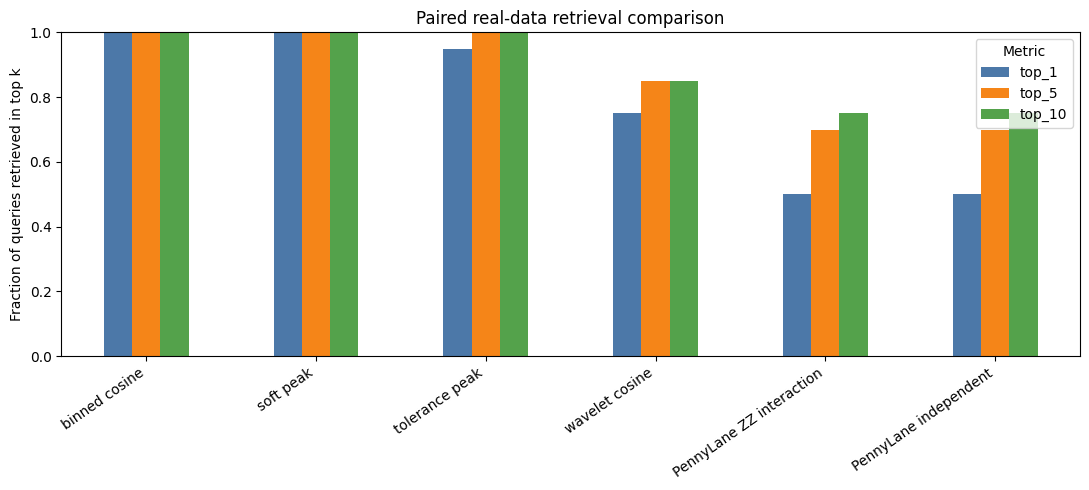

Query molecule: XKJMBINCVNINCA


,rank,score,inchikey,precursor_mz,is_true_molecule
64,1,0.999997,HXFOXFJUNFFYMO,175.071,False
11,2,0.999992,RFMMMVDNIPUKGG,190.071,False
18,3,0.999988,AQHHHDLHHXJYJD,260.165,False
94,4,0.999969,PZBPKYOVPCNPJY,297.056,False
38,5,0.999967,WXUZAHCNPWONDH,327.170,False
82,6,0.999962,JJIHLJJYMXLCOY,148.060,False
44,7,0.999959,FRQMUZJSZHZSGN,345.242,False
10,8,0.999955,ULGZDMOVFRHVEP,734.469,False
84,9,0.999955,JYGXADMDTFJGBT,363.217,False
52,10,0.999954,QIVBCDIJIAJPQS,205.097,False


In [12]:
all_summary.to_csv(OUTPUT_DIR / 'method_summary.csv', index=False)
pd.concat([classical_results, wavelet_results, quantum_results], ignore_index=True).to_csv(OUTPUT_DIR / 'query_ranks.csv', index=False)

plot_summary = all_summary.set_index('method')[['top_1', 'top_5', 'top_10']]
ax = plot_summary.plot(kind='bar', figsize=(11, 5), ylim=(0, 1), color=['#4C78A8', '#F58518', '#54A24B'])
ax.set_ylabel('Fraction of queries retrieved in top k')
ax.set_xlabel('')
ax.set_title('Paired real-data retrieval comparison')
ax.legend(title='Metric')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'method_summary.png', dpi=180)
plt.show()

# Show the top matches for the first query using the interaction kernel.
q_idx = 0
order = np.argsort(-interaction_scores[q_idx])[:10]
top_matches = library.iloc[order][['inchikey', 'precursor_mz']].copy()
top_matches.insert(0, 'rank', np.arange(1, len(top_matches) + 1))
top_matches.insert(1, 'score', interaction_scores[q_idx, order])
top_matches['is_true_molecule'] = top_matches['inchikey'].eq(queries.iloc[q_idx]['inchikey']).to_numpy()
print('Query molecule:', queries.iloc[q_idx]['inchikey'])
top_matches

In [13]:
from google.colab import drive
from pathlib import Path
import shutil

drive.mount('/content/drive')

save_location = Path('/content/drive/MyDrive/08-20-2026-MS-Results')
save_location.mkdir(parents=True, exist_ok=True)

output_folder = Path('/content/aug20_msms_outputs')

for file in output_folder.iterdir():
    shutil.copy2(file, save_location / file.name)

print(f'Saved outputs to: {save_location}')

MessageError: Error: credential propagation was unsuccessful